In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
drive_folder_path = '/content/drive/MyDrive/60 ẢNH'

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_augment = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode='nearest'
)

val_datagen_rescale = ImageDataGenerator(rescale=1.0/255)

In [5]:
filepaths = []
labels = []
for class_name in os.listdir(drive_folder_path):
    class_path = os.path.join(drive_folder_path, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            filepaths.append(img_path)
            labels.append(class_name)

df = pd.DataFrame({'filepath': filepaths, 'class': labels})
#xóa class gây nhiễu
excluded_classes = ['nguyen dong hai', 'nguyen thi thanh ha']
filtered_df = df[~df['class'].str.lower().isin([c.lower() for c in excluded_classes])]

train_df, val_df = train_test_split(filtered_df, test_size=0.2, stratify=filtered_df['class'], random_state=42)

train_generator = train_datagen_augment.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='class',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen_rescale.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='class',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

num_classes = len(train_generator.class_indices)
print(f"Number of classes after filtering: {num_classes}")

Found 1448 validated image filenames belonging to 29 classes.
Found 363 validated image filenames belonging to 29 classes.
Number of classes after filtering: 29


In [6]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(1024, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

input_tensor = Input(shape=(128, 128, 3))

base_model = MobileNetV2(input_tensor=input_tensor, include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

print("MobileNetV2 base model loaded and frozen. Custom classification layers added.")

/tmp/ipykernel_1322/118368116.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_tensor=input_tensor, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 base model loaded and frozen. Custom classification layers added.


In [8]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 12,759,133 (48.67 MB)

 Trainable params: 10,501,149 (40.06 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=10, monitor='val_accuracy', mode='max', restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=5, monitor='val_accuracy', mode='max'),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

In [10]:
epochs = 100
history = model.fit(train_generator, epochs=epochs, validation_data=val_generator, callbacks=callbacks)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.1127 - loss: 4.5464 
Epoch 1: val_accuracy improved from None to 0.58127, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1713s 37s/step - accuracy: 0.2030 - loss: 3.4248 - val_accuracy: 0.5813 - val_loss: 1.6133 - learning_rate: 1.0000e-04
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4162 - loss: 2.0952
Epoch 2: val_accuracy improved from 0.58127 to 0.70799, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.4655 - loss: 1.9056 - val_accuracy: 0.7080 - val_loss: 1.0773 - learning_rate: 1.0000e-04
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5386 - loss: 1.6244
Epoch 3: val_accuracy improved from 0.70799 to 0.76860, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.5628 - loss: 1.5652 - val_accuracy: 0.7686 - val_loss: 0.8928 - learning_rate: 1.0000e-04
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6301 - loss: 1.2418
Epoch 4: val_accuracy improved from 0.76860 to 0.79339, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.6533 - loss: 1.2176 - val_accuracy: 0.7934 - val_loss: 0.7330 - learning_rate: 1.0000e-04
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7275 - loss: 0.9775
Epoch 5: val_accuracy improved from 0.79339 to 0.81543, saving model to best_model.h5


...


Epoch 17: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.8612 - loss: 0.4717 - val_accuracy: 0.8953 - val_loss: 0.3365 - learning_rate: 1.0000e-04
Epoch 18/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8558 - loss: 0.5189
Epoch 18: val_accuracy did not improve from 0.89532
46/46 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8508 - loss: 0.4888 - val_accuracy: 0.8843 - val_loss: 0.3525 - learning_rate: 1.0000e-04
Epoch 19/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8457 - loss: 0.4750
Epoch 19: val_accuracy did not improve from 0.89532
46/46 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8577 - loss: 0.4450 - val_accuracy: 0.8898 - val_loss: 0.3415 - learning_rate: 1.0000e-04
Epoch 20/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8848 - loss: 0.3750
Epoch 20: val_accuracy did not improve from 0.89532
46/46 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8791 - loss: 0.3868 - val_accuracy: 0.8898 - val_loss: 0.


Epoch 23: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8881 - loss: 0.3465 - val_accuracy: 0.9008 - val_loss: 0.3347 - learning_rate: 5.0000e-05
Epoch 24/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9001 - loss: 0.3170
Epoch 24: val_accuracy did not improve from 0.90083
46/46 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9054 - loss: 0.3138 - val_accuracy: 0.8926 - val_loss: 0.3622 - learning_rate: 5.0000e-05
Epoch 25/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9290 - loss: 0.2521
Epoch 25: val_accuracy improved from 0.90083 to 0.90909, saving model to best_model.h5



Epoch 25: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9199 - loss: 0.2717 - val_accuracy: 0.9091 - val_loss: 0.3217 - learning_rate: 5.0000e-05
Epoch 26/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9127 - loss: 0.3188
Epoch 26: val_accuracy did not improve from 0.90909
46/46 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9171 - loss: 0.3154 - val_accuracy: 0.9008 - val_loss: 0.3405 - learning_rate: 5.0000e-05
Epoch 27/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9207 - loss: 0.2428
Epoch 27: val_accuracy did not improve from 0.90909
46/46 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9192 - loss: 0.2521 - val_accuracy: 0.8981 - val_loss: 0.3437 - learning_rate: 5.0000e-05
Epoch 28/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9015 - loss: 0.2938
Epoch 28: val_accuracy did not improve from 0.90909
46/46 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9081 - loss: 0.2831 - val_accuracy: 0.8898 - val_loss: 0.


Epoch 29: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9164 - loss: 0.2588 - val_accuracy: 0.9174 - val_loss: 0.2863 - learning_rate: 5.0000e-05
Epoch 30/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9270 - loss: 0.2252
Epoch 30: val_accuracy did not improve from 0.91736
46/46 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9206 - loss: 0.2512 - val_accuracy: 0.9063 - val_loss: 0.3131 - learning_rate: 5.0000e-05
Epoch 31/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9342 - loss: 0.2262
Epoch 31: val_accuracy did not improve from 0.91736
46/46 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9316 - loss: 0.2296 - val_accuracy: 0.9118 - val_loss: 0.3093 - learning_rate: 5.0000e-05
Epoch 32/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9274 - loss: 0.2505
Epoch 32: val_accuracy did not improve from 0.91736
46/46 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9247 - loss: 0.2597 - val_accuracy: 0.9091 - val_loss: 0.


Epoch 35: finished saving model to best_model.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9247 - loss: 0.2283 - val_accuracy: 0.9229 - val_loss: 0.3022 - learning_rate: 2.5000e-05
Epoch 36/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9400 - loss: 0.2096
Epoch 36: val_accuracy did not improve from 0.92287
46/46 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9468 - loss: 0.1861 - val_accuracy: 0.9091 - val_loss: 0.3055 - learning_rate: 2.5000e-05
Epoch 37/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9484 - loss: 0.1789
Epoch 37: val_accuracy did not improve from 0.92287
46/46 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9454 - loss: 0.1943 - val_accuracy: 0.9146 - val_loss: 0.2985 - learning_rate: 2.5000e-05
Epoch 38/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9528 - loss: 0.1834
Epoch 38: val_accuracy did not improve from 0.92287
46/46 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9523 - loss: 0.1790 - val_accuracy: 0.9091 - val_loss: 0.

In [11]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9229 - loss: 0.3022
Validation Loss: 0.3022
Validation Accuracy: 0.9229


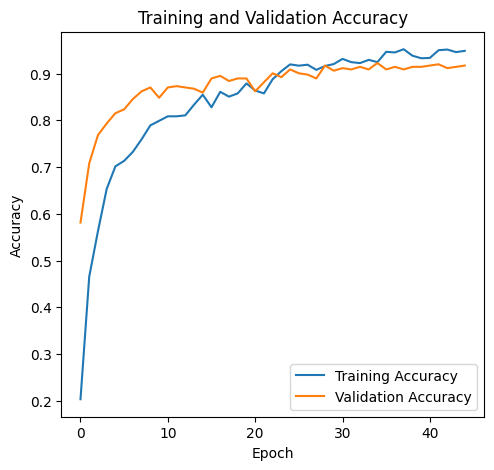

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

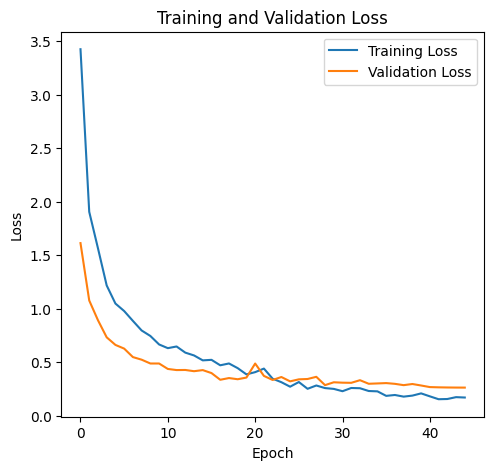

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

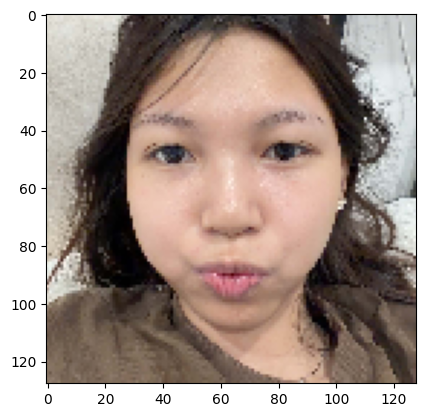

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Người trong ảnh là: NGUYEN BAO HAN


In [24]:
from keras.utils import load_img
import numpy as np
path = '/content/bhan.jpg'
img = load_img(path,target_size=(128,128))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/255.0
img=img.reshape(1,128,128,3)
prediction = np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
predicted_class = class_labels[prediction]
print(f"Người trong ảnh là: {predicted_class}")

In [23]:
model.save('my_image_classification_model.keras')